In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import STL
import statistics 

from sklearn.model_selection import train_test_split
import xgboost as xgb

from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

In [157]:
AI_dataset = pd.read_csv('AI_dataset.csv')
AI_dataset['Unnamed: 0'] = pd.DatetimeIndex(AI_dataset['Unnamed: 0'])
AI_dataset = AI_dataset.set_index('Unnamed: 0')
AI_dataset.index.names = ['index']
print(AI_dataset)

             Domanda   Offerta  deltalog     delta   Z-score
index                                                       
2017-01-01  0.050450  1.780786  0.973515  1.730337  2.299880
2017-01-02  0.070770  0.979433  0.614433  0.908663  1.311624
2017-01-03  0.060259  1.038792  0.653844  0.978533  1.420091
2017-01-04  0.069835  1.157511  0.701451  1.087676  1.551112
2017-01-05  0.063296  1.323223  0.781582  1.259928  1.771648
...              ...       ...       ...       ...       ...
2026-02-15  1.164780  1.065999 -0.046705 -0.098781 -0.507937
2026-02-16  1.303984  1.103098 -0.091228 -0.200885 -0.630472
2026-02-17  1.433144  1.503775  0.028615  0.070631 -0.300643
2026-02-18  1.480324  1.256444 -0.094599 -0.223880 -0.639749
2026-02-19  1.425904  1.246551 -0.076808 -0.179353 -0.590786

[3337 rows x 5 columns]


In [158]:
AI_dataset['deltalog'] = AI_dataset['deltalog'].fillna(0)
validation = AI_dataset['deltalog']

#time series decomposition
stl = STL(validation, robust=True) 
result = stl.fit()

trend = result.trend
seasonal = result.seasonal
remainder = result.resid

# Calculate IQR Bounds on the Remainder
Q1 = remainder.quantile(0.05)
Q3 = remainder.quantile(0.95)
IQR = Q3 - Q1

# The multiplier 'c' controls the sensitivity (similar to R's alpha). 
c = 1
lower_resid_bound = Q1 - (c * IQR)
upper_resid_bound = Q3 + (c * IQR)


expected_value = trend + seasonal
lower_bound = expected_value + lower_resid_bound
upper_bound = expected_value + upper_resid_bound


# An anomaly is anything outside the recomposed bounds
is_anomaly = (validation < lower_bound) | (validation > upper_bound)
anomalies = validation[is_anomaly]

print(anomalies)


index
2017-01-17    1.668040
2017-12-01    0.000000
2017-12-11    1.572108
2017-12-13    1.291385
2018-01-06    1.542258
2018-01-07    1.153691
2018-04-02    1.090252
2018-04-22   -0.259047
2019-01-31   -0.573387
2019-06-12   -0.603009
2019-08-13   -0.712055
2019-10-24   -1.607965
2020-08-02    0.605401
2021-04-04   -0.737658
2023-01-31   -0.850806
2023-03-25    0.540713
2023-03-26    0.738485
2023-10-02   -1.485448
2023-10-03   -1.148765
2023-11-06   -0.983702
2023-11-07   -1.602603
2023-11-08   -1.829301
2025-01-21   -1.032314
2025-01-22   -1.157406
2025-01-23   -1.367839
2025-01-24   -1.865365
2025-01-25   -2.268711
2025-01-26   -2.849604
2025-01-27   -3.662653
2025-01-28   -3.375552
2025-01-29   -3.062074
2025-01-30   -2.690120
2025-02-08   -1.355286
2025-02-13   -1.623097
2025-12-06   -0.937251
Name: deltalog, dtype: float64


In [159]:
# we are trying to build a XGBoost model to classify if the next point on a 2 day window will be an anomaly. 
#to do this we need features of the dataset 
anomalies = anomalies.reset_index()

XGBdata = AI_dataset
XGBdata['anomalies label'] = 0
XGBdata.loc[anomalies['index'], 'anomalies label'] = 1
XGBdata = XGBdata.drop(columns= 'Domanda', axis=1) 
XGBdata = XGBdata.drop(columns= 'Offerta', axis=1)
XGBdata = XGBdata.drop(columns= 'delta', axis=1)
XGBdata = XGBdata.drop(columns= 'Z-score', axis=1)

#features to feed into XGBoosted model
XGBdata['anomalies in 2 days'] =( (XGBdata['anomalies label'].shift(-1 ) ==1) | (XGBdata['anomalies label'].shift(-2) == 1)).astype(int)
XGBdata['deltalog_lag-1'] = XGBdata['deltalog'].shift(1)
XGBdata['Time difference'] = XGBdata['deltalog'].diff()
XGBdata['Time difference abs'] = XGBdata['Time difference'].abs()
XGBdata['Rolling mean_7'] = XGBdata['deltalog'].shift(1).rolling(window=14).mean()
XGBdata['Rolling std_7'] = XGBdata['deltalog'].shift(1).rolling(window=14).std()
XGBdata['rolling Z-score'] = (XGBdata['deltalog']- XGBdata['Rolling mean_7'])/XGBdata['Rolling std_7']



print(XGBdata.head(10))

            deltalog  anomalies label  anomalies in 2 days  deltalog_lag-1  \
index                                                                        
2017-01-01  0.973515                0                    0             NaN   
2017-01-02  0.614433                0                    0        0.973515   
2017-01-03  0.653844                0                    0        0.614433   
2017-01-04  0.701451                0                    0        0.653844   
2017-01-05  0.781582                0                    0        0.701451   
2017-01-06  0.783299                0                    0        0.781582   
2017-01-07  0.631127                0                    0        0.783299   
2017-01-08  0.667761                0                    0        0.631127   
2017-01-09  0.599245                0                    0        0.667761   
2017-01-10  0.717736                0                    0        0.599245   

            Time difference  Time difference abs  Rolling mean_

In [160]:
#now that we have the feature, and data, let's clean
XGBdata_clean = XGBdata.dropna().copy()
XGBdata_clean = XGBdata_clean.reset_index(drop= True)

#let's create the features and target values r x and y dataset

features = ['Time difference', 'Time difference abs', 'deltalog', 'deltalog_lag-1','Rolling mean_7', 'Rolling std_7', 'rolling Z-score' ]
X = XGBdata_clean[features]
Y = XGBdata_clean['anomalies in 2 days']

#let's create the parameter that will tell us if the model is accurate

print(Y, X)


0       1
1       1
2       0
3       0
4       0
       ..
3315    0
3316    0
3317    0
3318    0
3319    0
Name: anomalies in 2 days, Length: 3320, dtype: int64       Time difference  Time difference abs  deltalog  deltalog_lag-1  \
0           -0.030151             0.030151  0.491538        0.521689   
1            0.660775             0.660775  1.152314        0.491538   
2            0.515727             0.515727  1.668040        1.152314   
3           -0.855832             0.855832  0.812209        1.668040   
4           -0.150820             0.150820  0.661389        0.812209   
...               ...                  ...       ...             ...   
3315        -0.007120             0.007120 -0.046705       -0.039585   
3316        -0.044523             0.044523 -0.091228       -0.046705   
3317         0.119843             0.119843  0.028615       -0.091228   
3318        -0.123215             0.123215 -0.094599        0.028615   
3319         0.017791             0.017791 -

In [256]:
#let's divide the dataset into test and train with 80& 20%
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.20, shuffle= False)

num_anom = (Y_test== 1).sum()
num_not_anome = (Y_test == 0).sum()
scale_pos_weight_value = (num_not_anome / num_anom) 


model = xgb.XGBClassifier(
    scale_pos_weight = scale_pos_weight_value,
    eval_metric = 'aucpr',
    random_state = 1, #so every time we get the same results,
    min_child_weight = 10,
    learning_rate = 0.05,
    colsample_bytree = 0.7, 
    n_estimator = 1000
)

model.fit(X_train, Y_train)

/var/data/python/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:02:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [257]:

# Prediction of the model
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class
y_pred_final = (y_pred_proba >= 0.805).astype(int) #this is the confidence interval

# 2.classification report 
print("Classification Report")
# Look strictly at the row for class '1'.
print(classification_report(Y_test, y_pred_final))

# 3. Calculate PR-AUC
pr_auc = average_precision_score(Y_test, y_pred_proba)
print(pr_auc)

# 4. Print the Confusion Matrix
print("\n-Confusion Matrix")
cm = confusion_matrix(Y_test, y_pred_final)
print(cm)
#it's     egative- positive 
#negative 
#positive


print(f"True Negatives (Normal correctly ignored): {cm[0][0]}")
print(f"False Positives (False Alarms): {cm[0][1]}")
print(f"False Negatives (Missed Anomalies): {cm[1][0]}")
print(f"True Positives (Successfully Predicted Anomalies): {cm[1][1]}")

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       647
           1       0.67      0.24      0.35        17

    accuracy                           0.98       664
   macro avg       0.82      0.62      0.67       664
weighted avg       0.97      0.98      0.97       664

0.26954488603716076

-Confusion Matrix
[[645   2]
 [ 13   4]]
True Negatives (Normal correctly ignored): 645
False Positives (False Alarms): 2
False Negatives (Missed Anomalies): 13
True Positives (Successfully Predicted Anomalies): 4


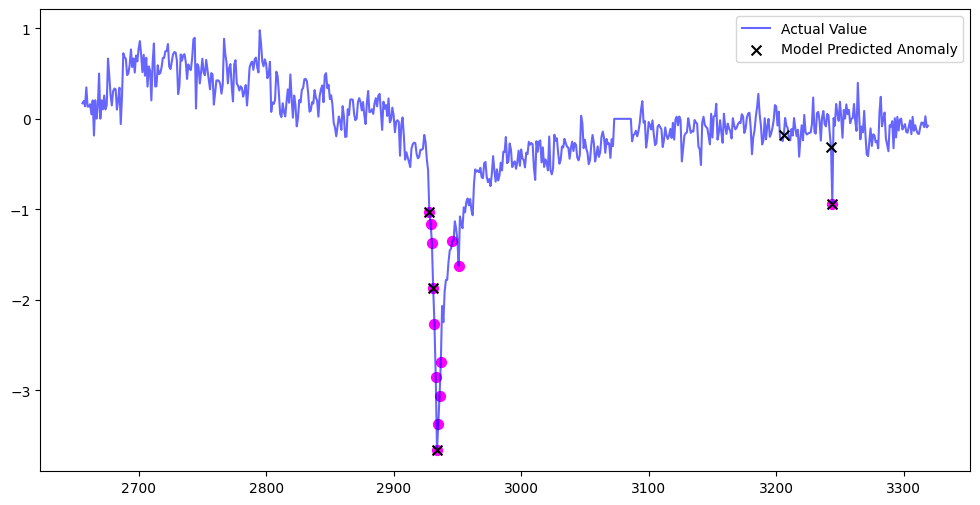

In [247]:


# Create a copy of your test dataframe so we can plot it safely
plot_df = X_test.copy()
plot_df['Actual_Anomaly_Window'] = Y_test
plot_df['Predicted_Anomaly_Window'] = y_pred_final


# Plot the raw values
plt.figure(figsize=(12, 6))
plt.plot(plot_df.index, plot_df['deltalog'], label='Actual Value', color='blue', alpha=0.6)

#Highlight where the model PREDICTED an anomaly
predicted_anomalies = plot_df[plot_df['Predicted_Anomaly_Window'] == 1]

plt.scatter(predicted_anomalies.index, predicted_anomalies['deltalog'], 
            color='black', label='Model Predicted Anomaly', marker='x', s=50, zorder = 5)

anomalies_value = pd.DataFrame()
anomalies_value = XGBdata_clean['deltalog'][(XGBdata_clean['anomalies label'] == 1) & (XGBdata_clean.index >= 2655 )] 


plt.scatter(anomalies_value.index, anomalies_value, color = 'magenta', s = 50)

plt.legend()
plt.show()